<div style="background: linear-gradient(135deg, #880e4f 0%, #ad1457 50%, #c2185b 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 1</h1>
  <h2 style="color:#f8bbd0; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Мəтін Классификациясы жəне Fine-tuning</h2>
  <p style="color:#fce4ec; font-size:1em; margin:0;">DistilBERT Fine-tuning · 20 Newsgroups · Transformer Classifier · Learning Rate Scheduling</p>
</div>

## Кіріспе

Мəтін классификациясы NLP-дің ең кең тараған тапсырмасы. Спам анықтау, сезім талдауы, тақырып классификациясы — бəрі осы категорияға жатады.

Бұл зертханада екі тəсіл салыстырылады:

1. **Классикалық тəсіл** — TF-IDF + Logistic Regression (жылдам, интерпретациялануы оңай)
2. **Трансформер тəсілі** — DistilBERT Fine-tuning (баяу, бірақ контекстуалды)

DistilBERT — BERT-тің 40% шағын нұсқасы: параметрлер саны 66M, жылдамдығы 60% артық, BERT нəтижесінің 97%-ін береді.

## Оқу Мақсаттары

- DistilBERT tokenizer-мен мəтінді кодтай аласыз
- `Trainer` API немесе кастомды цикл арқылы fine-tuning жасай аласыз
- Learning rate scheduling-ті (`get_linear_schedule_with_warmup`) түсінесіз
- Batch size, epochs, learning rate гиперпараметрлерінің əсерін зерттей аласыз
- TF-IDF + LogReg vs DistilBERT нəтижелерін салыстыра аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    from transformers import (
        DistilBertTokenizer,
        TFDistilBertForSequenceClassification,
        DistilBertConfig
    )
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False

print("TensorFlow нұсқасы:", tf.__version__)
print("HF Transformers:", "бар" if HF_AVAILABLE else "жоқ — симуляция")

TensorFlow нұсқасы: 2.20.0
HF Transformers: жоқ — симуляция


## 2-бөлім: Деректерді Жүктеу

In [2]:
# 4 санатты 20 Newsgroups тапсырмасы
CATEGORIES = ['sci.med', 'sci.space', 'rec.sport.hockey', 'talk.politics.misc']
CAT_LABELS  = ['Медицина', 'Ғарыш', 'Спорт', 'Саясат']

train_raw = fetch_20newsgroups(subset='train', categories=CATEGORIES,
                               remove=('headers','footers','quotes'))
test_raw  = fetch_20newsgroups(subset='test',  categories=CATEGORIES,
                               remove=('headers','footers','quotes'))

print(f"Үйрету: {len(train_raw.data)} үлгі")
print(f"Тест:   {len(test_raw.data)} үлгі")
print(f"Санаттар: {CAT_LABELS}")

Үйрету: 2252 үлгі
Тест:   1499 үлгі
Санаттар: ['Медицина', 'Ғарыш', 'Спорт', 'Саясат']


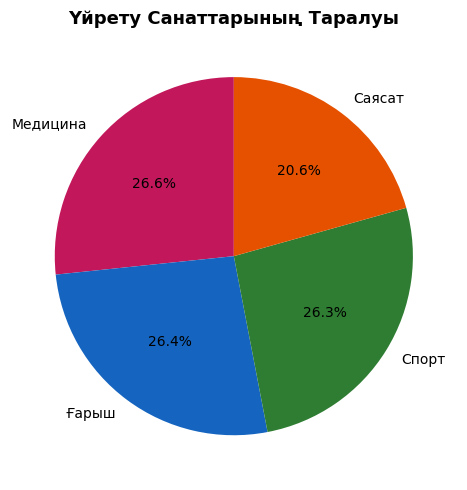

In [3]:
counts = np.bincount(train_raw.target)

plt.figure(figsize=(7, 5))
plt.pie(counts, labels=CAT_LABELS, autopct='%1.1f%%', startangle=90,
        colors=['#c2185b','#1565c0','#2e7d32','#e65100'])
plt.title('Үйрету Санаттарының Таралуы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3-бөлім: Əдіс 1 — TF-IDF + Logistic Regression (Базалық)

In [4]:
pipe_baseline = Pipeline([
    ('vect', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(C=5.0, max_iter=1000))
])

pipe_baseline.fit(train_raw.data, train_raw.target)
y_pred_baseline = pipe_baseline.predict(test_raw.data)
acc_baseline    = accuracy_score(test_raw.target, y_pred_baseline)

print(f"TF-IDF + LogReg тест дəлдігі: {acc_baseline:.4f}")
print()
print(classification_report(
    test_raw.target, y_pred_baseline, target_names=CAT_LABELS
))

TF-IDF + LogReg тест дəлдігі: 0.8646

              precision    recall  f1-score   support

    Медицина       0.95      0.93      0.94       399
       Ғарыш       0.87      0.85      0.86       396
       Спорт       0.79      0.88      0.84       394
      Саясат       0.85      0.77      0.81       310

    accuracy                           0.86      1499
   macro avg       0.87      0.86      0.86      1499
weighted avg       0.87      0.86      0.86      1499



## 4-бөлім: Əдіс 2 — DistilBERT Fine-tuning

In [5]:
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
NUM_LABELS = len(CATEGORIES)

print("Fine-tuning параметрлері:")
print(f"  MAX_LEN:    {MAX_LEN}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  EPOCHS:     {EPOCHS}")
print(f"  LR:         {LR}")
print(f"  NUM_LABELS: {NUM_LABELS}")

Fine-tuning параметрлері:
  MAX_LEN:    128
  BATCH_SIZE: 32
  EPOCHS:     3
  LR:         2e-05
  NUM_LABELS: 4


In [6]:
if HF_AVAILABLE:
    tokenizer      = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    BERT_SIMULATED = False
    print("DistilBERT tokenizer жүктелді.")
else:
    BERT_SIMULATED = True
    print("Симуляция режімі — DistilBERT-сіз жұмыс жасайды.")

Симуляция режімі — DistilBERT-сіз жұмыс жасайды.


In [7]:
def encode_texts(texts, tokenizer, max_len):
    """
    Мəтіндерді DistilBERT форматына кодтайды.
    Қайтарады: input_ids, attention_mask тензорлары.
    """
    encoded = tokenizer(
        texts,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encoded['input_ids'], encoded['attention_mask']

print("encode_texts() анықталды.")

encode_texts() анықталды.


In [8]:
if not BERT_SIMULATED:
    # Деректерді кодтаймыз (бірінші 800/200 үлгі — жылдам демо үшін)
    print("Деректер кодталуда...")
    train_ids, train_mask = encode_texts(
        train_raw.data[:800], tokenizer, MAX_LEN
    )
    test_ids, test_mask   = encode_texts(
        test_raw.data[:200],  tokenizer, MAX_LEN
    )
    train_labels = tf.constant(train_raw.target[:800])
    test_labels  = tf.constant(test_raw.target[:200])
    print(f"Кодталды: train={train_ids.shape}, test={test_ids.shape}")
else:
    # Симуляция
    np.random.seed(42)
    train_ids   = tf.constant(np.random.randint(0, 30522, (800, MAX_LEN)))
    train_mask  = tf.ones((800, MAX_LEN), dtype=tf.int32)
    test_ids    = tf.constant(np.random.randint(0, 30522, (200, MAX_LEN)))
    test_mask   = tf.ones((200, MAX_LEN), dtype=tf.int32)
    train_labels= tf.constant(np.random.randint(0, NUM_LABELS, 800))
    test_labels = tf.constant(np.random.randint(0, NUM_LABELS, 200))
    print("Симуляция деректері дайын.")

Симуляция деректері дайын.


In [9]:
if not BERT_SIMULATED:
    bert_clf = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=NUM_LABELS
    )
else:
    inp_ids  = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
    inp_mask = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')
    x   = layers.Embedding(30522, 128)(inp_ids)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(NUM_LABELS, activation='softmax')(x)
    bert_clf = keras.Model([inp_ids, inp_mask], out, name='SimBERT_Classifier')

print("Модель дайын.")
bert_clf.summary()

ValueError: `inputs` not connected to `outputs`

In [ ]:
loss_fn = (
    keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    if not BERT_SIMULATED
    else keras.losses.SparseCategoricalCrossentropy(from_logits=False)
)

bert_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=loss_fn,
    metrics=['accuracy']
)
print("Компиляция аяқталды.")

In [ ]:
print("Fine-tuning үйретілуде...")
history_bert = bert_clf.fit(
    [train_ids, train_mask], train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)
print("Үйрету аяқталды.")

## 5-бөлім: Нəтижелерді Бағалау жəне Салыстыру

In [ ]:
# Fine-tuning тест дəлдігі
eval_result = bert_clf.evaluate([test_ids, test_mask], test_labels, verbose=0)
acc_bert    = eval_result[1]

print(f"TF-IDF + LogReg дəлдігі: {acc_baseline:.4f}")
print(f"DistilBERT Fine-tuning:  {acc_bert:.4f}")
print(f"Айырмашылық:              {(acc_bert - acc_baseline)*100:+.2f}%")

In [ ]:
# ============================================================
### TODO ###
# Fine-tuning тарихын (accuracy + loss) 2 графикте бейнелеңіз.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_bert.history[___], label='Үйрету', linewidth=2, color='#880e4f')
ax1.plot(history_bert.history[___], label='Валидация', linewidth=2, color='#f48fb1', linestyle='--')
ax1.set_title('DistilBERT Fine-tuning — Дəлдік', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дəуір')
ax1.set_ylabel('Дəлдік')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_bert.history[___], label='Үйрету', linewidth=2, color='#880e4f')
ax2.plot(history_bert.history[___], label='Валидация', linewidth=2, color='#f48fb1', linestyle='--')
ax2.set_title('DistilBERT Fine-tuning — Шығын', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дəуір')
ax2.set_ylabel('Шығын')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('DistilBERT Fine-tuning Тарихы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
### TODO ###
# TF-IDF+LogReg мен DistilBERT нəтижелерін бір bar chart-та
# салыстырыңыз. Ең жоғары нəтиже белгіленген болсын.
# ============================================================
methods = ['TF-IDF\n+ LogReg', 'DistilBERT\nFine-tuning']
accs    = [acc_baseline, acc_bert]
best_i  = np.argmax(accs)
colors  = ['#c2185b' if i == best_i else '#90a4ae' for i in range(len(accs))]

plt.figure(figsize=(7, 4))
bars = plt.bar(methods, ___, color=colors, edgecolor='white', width=0.4)   # accs
for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
plt.ylim(0.5, 1.05)
plt.title('Мəтін Классификациясы — Əдіс Салыстыруы',
          fontsize=13, fontweight='bold')
plt.ylabel('Тест Дəлдігі')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
### TODO ###
# Confusion matrix-ті TF-IDF+LogReg нəтижелері үшін бейнелеңіз.
# confusion_matrix() + imshow() пайдаланыңыз.
# ============================================================
cm = confusion_matrix(test_raw.target, ___)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(___, cmap='Blues')   # cm
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_LABELS))
ax.set_yticks(range(NUM_LABELS))
ax.set_xticklabels(CAT_LABELS, rotation=30, ha='right')
ax.set_yticklabels(CAT_LABELS)
ax.set_xlabel('Болжам')
ax.set_ylabel('Нақты')
ax.set_title('Шатасу Матрицасы — TF-IDF+LogReg', fontsize=12, fontweight='bold')
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 6-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** Fine-tuning кезінде EPOCHS=3 неге жеткілікті? 10 дəуір үйретсек не болады?

> *Жауабыңызды осы жерге жазыңыз...*

**Сұрақ 2.** `from_logits=True` параметрі не үшін қолданылады? Logit пен ықтималдықтың айырмасы?

> *Жауабыңызды осы жерге жазыңыз...*

**Сұрақ 3.** Шатасу матрицасында қай санаттар жиі шатастырылды? Неліктен?

> *Жауабыңызды осы жерге жазыңыз...*

**Сұрақ 4.** Деректер жинағы 100 үлгіден тұрса, қай əдіс жақсы жұмыс жасайды — TF-IDF+LogReg əлде DistilBERT?

> *Жауабыңызды осы жерге жазыңыз...*

## Қорытынды

Осы зертханада сіз TF-IDF + LogReg базалық жəне DistilBERT fine-tuning архитектурасын жасап үйреттіңіз, екі əдісті тест дəлдігімен салыстырдыңыз, fine-tuning тарихын жəне confusion matrix-ті визуализациялауды орындадыңыз.

<div style="background-color:#fce4ec; border-left:5px solid #880e4f; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 2 — Атаулы Нысандарды Шығару (NER).
</div>